In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('informacion_campana_bancaria_2026.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,single,basic.9y,no,yes,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,yes
1,58,retired,married,professional.course,no,yes,no,cellular,aug,mon,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
2,48,technician,married,professional.course,no,yes,yes,cellular,nov,fri,...,3,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no
3,39,blue-collar,single,basic.9y,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.483,5099.1,no
4,56,services,married,basic.4y,NaN,no,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41383,21,unemployed,married,high.school,no,yes,yes,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
41384,24,blue-collar,single,basic.9y,no,yes,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
41385,21,student,single,basic.4y,no,no,no,cellular,mar,mon,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.520,5099.1,no
41386,52,admin.,married,high.school,no,no,no,cellular,nov,fri,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41388 entries, 0 to 41387
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41388 non-null  int64  
 1   job             41054 non-null  str    
 2   marital         41307 non-null  str    
 3   education       39644 non-null  str    
 4   default         32743 non-null  str    
 5   housing         40392 non-null  str    
 6   loan            40392 non-null  str    
 7   contact         41388 non-null  str    
 8   month           41388 non-null  str    
 9   day_of_week     41388 non-null  str    
 10  duration        41388 non-null  int64  
 11  campaign        41388 non-null  int64  
 12  pdays           41388 non-null  int64  
 13  previous        41388 non-null  int64  
 14  poutcome        41388 non-null  str    
 15  emp.var.rate    41388 non-null  float64
 16  cons.price.idx  41388 non-null  float64
 17  cons.conf.idx   41388 non-null  float64
 1

In [4]:
(df.isnull().sum()/df.shape[0])*100

age                0.000000
job                0.806997
marital            0.195709
education          4.213782
default           20.887697
housing            2.406495
loan               2.406495
contact            0.000000
month              0.000000
day_of_week        0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     0.000000
cons.conf.idx      0.000000
euribor3m          0.000000
nr.employed        0.000000
y                  0.000000
dtype: float64

In [5]:
df.duplicated().sum()

np.int64(12)

In [6]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
6838,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
9976,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
19829,55,services,married,high.school,NaN,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
22582,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
22626,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
24813,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
24973,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
34832,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
36112,71,retired,single,university.degree,no,no,no,telephone,oct,tue,...,1,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,no
39908,45,admin.,married,university.degree,no,no,no,cellular,jul,thu,...,1,999,0,nonexistent,-2.9,92.469,-33.6,1.072,5076.2,yes


In [7]:
# Mostrar registros completamente duplicados
duplicados = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

print(f"Total de filas duplicadas: {df.duplicated().sum()}")
print(f"Filas que aparecen como duplicadas (todas las copias): {len(duplicados)}\n")

duplicados

Total de filas duplicadas: 12
Filas que aparecen como duplicadas (todas las copias): 24



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
23793,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
41123,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
2168,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
22626,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
26139,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
34832,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
4049,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
6838,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
24943,36,retired,married,NaN,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
40229,36,retired,married,NaN,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [8]:
df_rev = df.drop_duplicates()

In [9]:
df_rev

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,single,basic.9y,no,yes,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,yes
1,58,retired,married,professional.course,no,yes,no,cellular,aug,mon,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
2,48,technician,married,professional.course,no,yes,yes,cellular,nov,fri,...,3,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no
3,39,blue-collar,single,basic.9y,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.483,5099.1,no
4,56,services,married,basic.4y,NaN,no,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41383,21,unemployed,married,high.school,no,yes,yes,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
41384,24,blue-collar,single,basic.9y,no,yes,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
41385,21,student,single,basic.4y,no,no,no,cellular,mar,mon,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.520,5099.1,no
41386,52,admin.,married,high.school,no,no,no,cellular,nov,fri,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no


In [10]:
df_rev.info()

<class 'pandas.DataFrame'>
Index: 41376 entries, 0 to 41387
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41376 non-null  int64  
 1   job             41042 non-null  str    
 2   marital         41295 non-null  str    
 3   education       39633 non-null  str    
 4   default         32732 non-null  str    
 5   housing         40380 non-null  str    
 6   loan            40380 non-null  str    
 7   contact         41376 non-null  str    
 8   month           41376 non-null  str    
 9   day_of_week     41376 non-null  str    
 10  duration        41376 non-null  int64  
 11  campaign        41376 non-null  int64  
 12  pdays           41376 non-null  int64  
 13  previous        41376 non-null  int64  
 14  poutcome        41376 non-null  str    
 15  emp.var.rate    41376 non-null  float64
 16  cons.price.idx  41376 non-null  float64
 17  cons.conf.idx   41376 non-null  float64
 18  eu

In [11]:
# Reemplar nulos con 'unknown' en variables categóricas

df_rev['job'] = df_rev['job'].fillna('unknown')
df_rev['marital'] = df_rev['marital'].fillna('unknown')
df_rev['education'] = df_rev['education'].fillna('unknown')
df_rev['default'] = df_rev['default'].fillna('unknown')
df_rev['housing'] = df_rev['housing'].fillna('unknown')
df_rev['loan'] = df_rev['loan'].fillna('unknown')

In [12]:
df_rev.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00
mean,40.03,257.07,2.57,962.50,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.30,2.78,186.86,0.49,1.57,0.58,4.63,1.73,72.24
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,101.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,179.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,318.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## Gráfico 'age'

In [13]:
df_rev['age'].describe().round(2)

count    41376.00
mean        40.03
std         10.42
min         17.00
25%         32.00
50%         38.00
75%         47.00
max         98.00
Name: age, dtype: float64

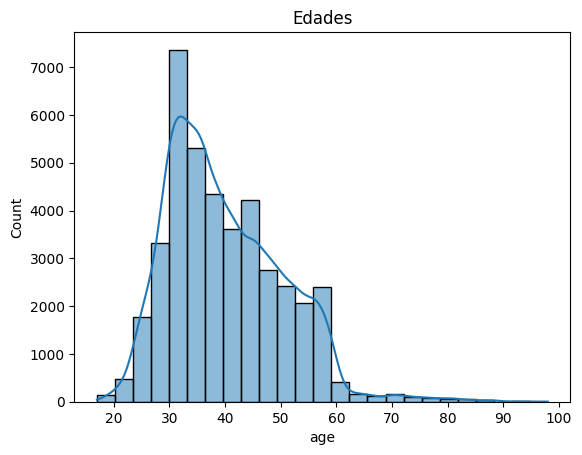

In [14]:
sns.histplot(data=df_rev, x="age", bins=25, kde=True)

plt.title("Edades")
plt.show()

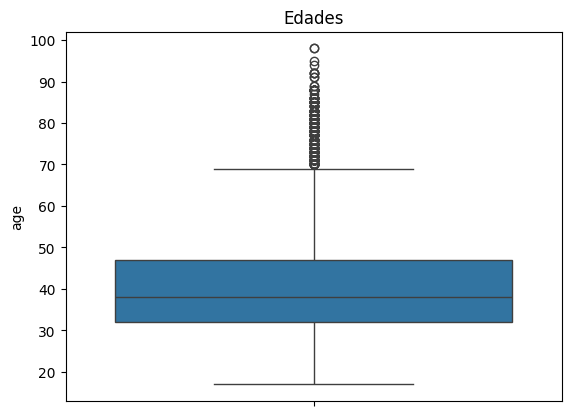

In [15]:
sns.boxplot(data=df_rev['age'])

plt.title("Edades")
plt.show()

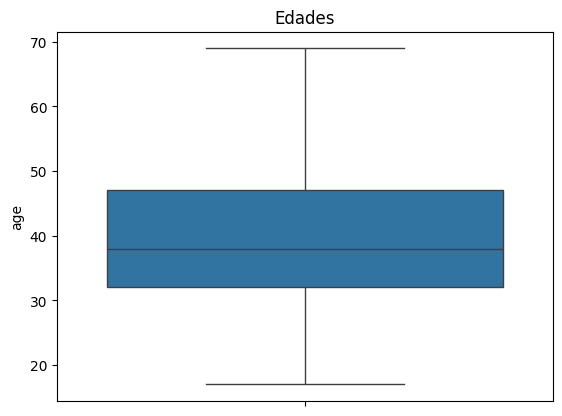

In [16]:
sns.boxplot(data=df_rev['age'], showfliers=False)

plt.title("Edades")
plt.show()

## Gráfico 'duration'

In [17]:
df_rev['duration'].describe().round(2)

count    41376.00
mean       257.07
std        259.30
min          0.00
25%        101.00
50%        179.00
75%        318.00
max       4918.00
Name: duration, dtype: float64

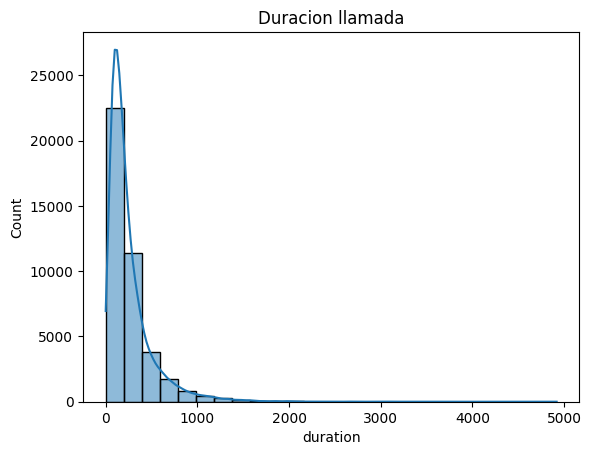

In [18]:
sns.histplot(data=df_rev, x="duration", bins=25, kde=True)

plt.title("Duracion llamada")
plt.show()

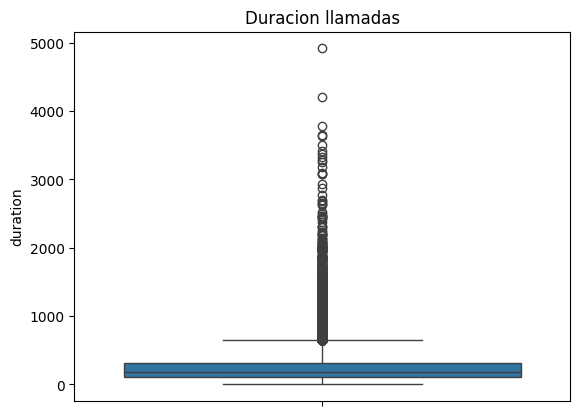

In [19]:
sns.boxplot(data=df_rev['duration'])

plt.title("Duracion llamadas")
plt.show()

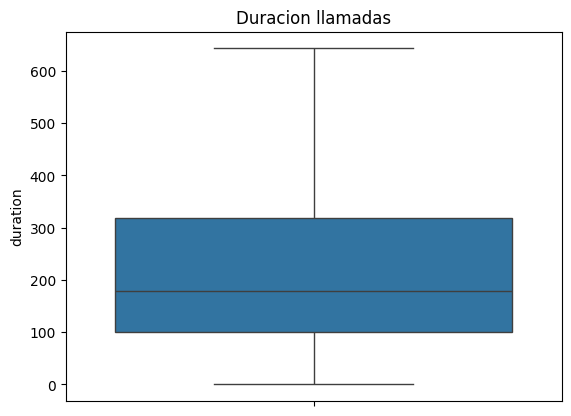

In [20]:
sns.boxplot(data=df_rev['duration'], showfliers=False)

plt.title("Duracion llamadas")
plt.show()

## Gráfico 'campaign'

In [21]:
df_rev['campaign'].describe().round(2)

count    41376.00
mean         2.57
std          2.78
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64

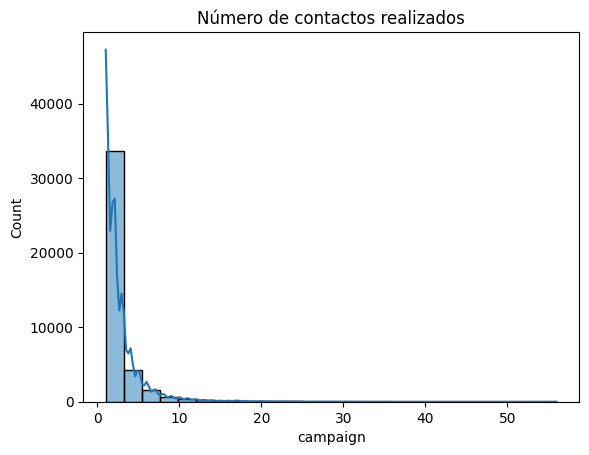

In [22]:
sns.histplot(data=df_rev, x="campaign", bins=25, kde=True)

plt.title("Número de contactos realizados")
plt.show()

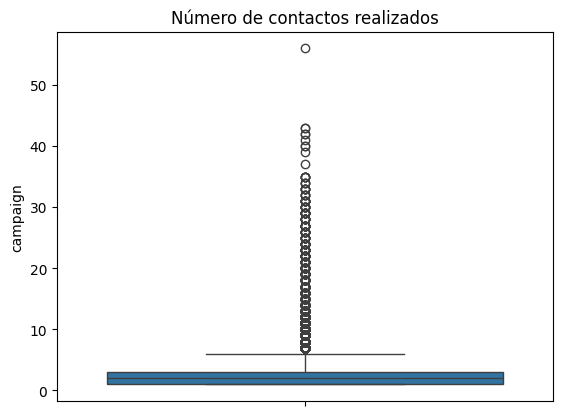

In [23]:
sns.boxplot(data=df_rev['campaign'])

plt.title("Número de contactos realizados")
plt.show()

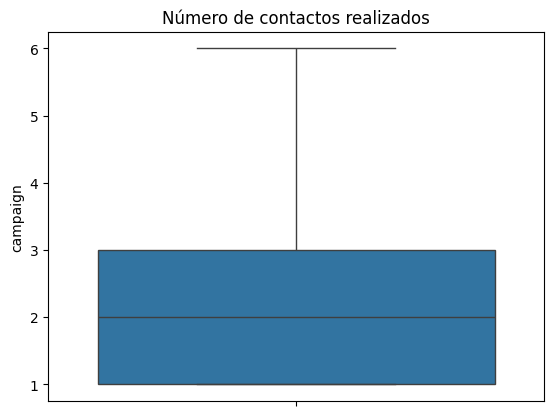

In [24]:
sns.boxplot(data=df_rev['campaign'], showfliers=False)

plt.title("Número de contactos realizados")
plt.show()

## Gráfico 'pdays'

In [25]:
df_rev['pdays'].describe().round(2)

count    41376.00
mean       962.50
std        186.86
min          0.00
25%        999.00
50%        999.00
75%        999.00
max        999.00
Name: pdays, dtype: float64

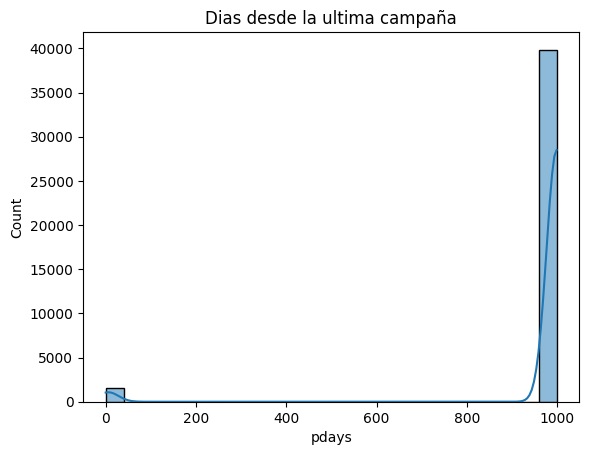

In [26]:
sns.histplot(data=df_rev, x="pdays", bins=25, kde=True)

plt.title("Dias desde la ultima campaña")
plt.show()

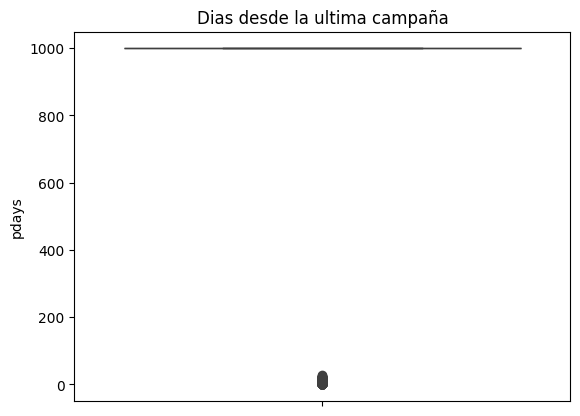

In [27]:
sns.boxplot(data=df_rev['pdays'])

plt.title("Dias desde la ultima campaña")
plt.show()

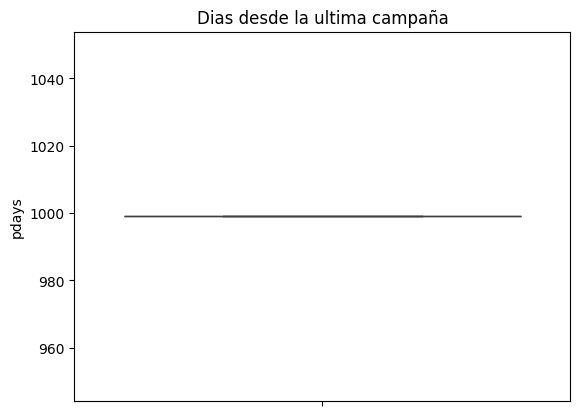

In [28]:
sns.boxplot(data=df_rev['pdays'], showfliers=False)

plt.title("Dias desde la ultima campaña")
plt.show()

## Gráfico 'previous'

In [29]:
df_rev['previous'].describe().round(2)

count    41376.00
mean         0.17
std          0.49
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          7.00
Name: previous, dtype: float64

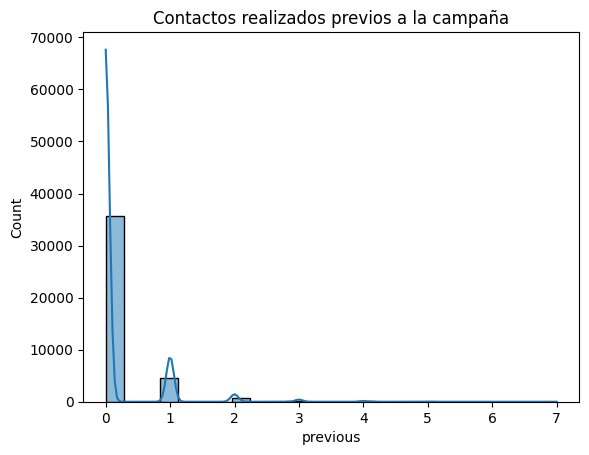

In [30]:
sns.histplot(data=df_rev, x="previous", bins=25, kde=True)

plt.title("Contactos realizados previos a la campaña")
plt.show()

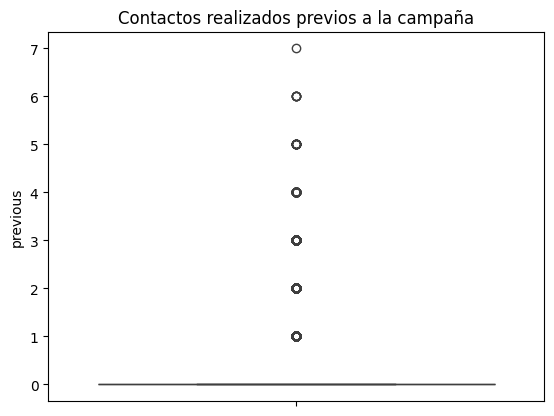

In [31]:
sns.boxplot(data=df_rev['previous'])

plt.title("Contactos realizados previos a la campaña")
plt.show()

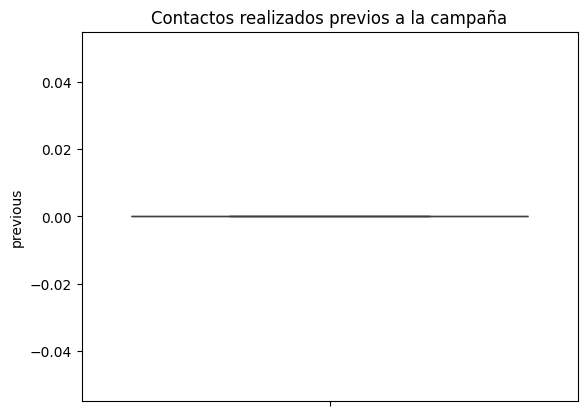

In [32]:
sns.boxplot(data=df_rev['previous'], showfliers=False)

plt.title("Contactos realizados previos a la campaña")
plt.show()

In [33]:
df_rev['q_age'] = pd.qcut(df_rev['age'], q=4, labels=['Q1 (17-32)', 'Q2 (32-38)', 'Q3 (38-47)', 'Q4 (47-98)'])

df_rev['q_age'].value_counts().sort_index()

q_age
Q1 (17-32)    11218
Q2 (32-38)    10050
Q3 (38-47)    10191
Q4 (47-98)     9917
Name: count, dtype: int64

In [34]:
df_rev['job'].value_counts()

job
admin.           10483
blue-collar       9294
technician        6776
services          3979
management        2933
retired           1726
entrepreneur      1463
self-employed     1427
housemaid         1065
unemployed        1018
student            878
unknown            334
Name: count, dtype: int64

In [35]:
# Recategorización de "job"
job_cat = {
    "admin.": "Formal",
    "blue-collar": "Informal",
    "entrepreneur": "Informal",
    "housemaid": "No Remunerado",
    "management": "Formal",
    "retired": "Formal",
    "self-employed": "Informal",
    "services": "Formal",
    "student": "No Remunerado",
    "technician": "Formal",
    "unemployed": "No Remunerado",
    "unknown": "Otros"
}

df_rev['job_cat'] = df_rev['job'].map(job_cat)

In [36]:
# pdays = 999 significa que el cliente NO fue contactado antes
# Creamos una columna nueva "contactado antes"
df_rev['contactado_antes'] = df_rev['pdays'].apply(
    lambda x: 'Sí' if x != 999 else 'No'
)

# comparamos cuántos clientes fueron contactados antes y cuántos no
print(df_rev['contactado_antes'].value_counts())
print(f"\nSolo el {round((df_rev['contactado_antes'] == 'Sí').mean() * 100, 2)}% de los clientes había sido contactado en campañas anteriores.")


contactado_antes
No    39855
Sí     1521
Name: count, dtype: int64

Solo el 3.68% de los clientes había sido contactado en campañas anteriores.


In [37]:
# Recategorización de "education"
edu_cat = {
    "basic.4y": "Basic",
    "basic.6y": "Basic",
    "basic.9y": "Basic",
    "high.school": "high.school",
    "illiterate": "illiterate",
    "professional.course": "professional.course",
    "university.degree": "university.degree",
    "unknown": "Otros"
}

df_rev['edu_cat'] = df_rev['education'].map(edu_cat)

In [38]:
df_rev

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,q_age,job_cat,contactado_antes,edu_cat
0,30,blue-collar,single,basic.9y,no,yes,no,telephone,jun,mon,...,1.4,94.465,-41.8,4.958,5228.1,yes,Q1 (17-32),Informal,No,Basic
1,58,retired,married,professional.course,no,yes,no,cellular,aug,mon,...,1.4,93.444,-36.1,4.970,5228.1,no,Q4 (47-98),Formal,No,professional.course
2,48,technician,married,professional.course,no,yes,yes,cellular,nov,fri,...,-0.1,93.200,-42.0,4.021,5195.8,no,Q4 (47-98),Formal,No,professional.course
3,39,blue-collar,single,basic.9y,no,yes,no,cellular,apr,thu,...,-1.8,93.075,-47.1,1.483,5099.1,no,Q3 (38-47),Informal,No,Basic
4,56,services,married,basic.4y,unknown,no,no,telephone,jun,mon,...,1.4,94.465,-41.8,4.865,5228.1,no,Q4 (47-98),Formal,No,Basic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41383,21,unemployed,married,high.school,no,yes,yes,cellular,jul,thu,...,1.4,93.918,-42.7,4.962,5228.1,no,Q1 (17-32),No Remunerado,No,high.school
41384,24,blue-collar,single,basic.9y,no,yes,no,cellular,jul,mon,...,1.4,93.918,-42.7,4.960,5228.1,no,Q1 (17-32),Informal,No,Basic
41385,21,student,single,basic.4y,no,no,no,cellular,mar,mon,...,-1.8,92.843,-50.0,1.520,5099.1,no,Q1 (17-32),No Remunerado,No,Basic
41386,52,admin.,married,high.school,no,no,no,cellular,nov,fri,...,-0.1,93.200,-42.0,4.021,5195.8,no,Q4 (47-98),Formal,No,high.school


Proyecto: Analítica de campañas de marketing en Banco Santander
Contexto del caso
El Banco Santander ha estado desarrollando campañas de marketing para promover uno de sus productos financieros: depósitos a plazo.
Estos depósitos permiten a los clientes invertir su dinero por un periodo determinado a cambio de una tasa de interés garantizada. Para aumentar la adopción del producto, el banco ha realizado campañas de marketing directo mediante llamadas telefónicas.
Durante estas campañas:
●	Los agentes del banco contactan a clientes existentes.

●	En muchos casos, se realizan múltiples llamadas al mismo cliente antes de obtener una respuesta definitiva.

●	El objetivo de cada llamada es ofrecer el producto y conocer si el cliente decide suscribirse al depósito a plazo.

El banco ha recopilado información detallada sobre estas campañas, incluyendo:
●	características de los clientes

●	historial de contactos

●	información de campañas anteriores

●	variables económicas del entorno

Finalmente, cada registro indica si el cliente aceptó ("yes") o no ("no") el producto ofrecido.
El problema de negocio
El equipo de marketing del Banco Santander quiere mejorar la eficiencia de sus campañas telefónicas.
Actualmente:
●	muchas llamadas no generan conversiones

●	algunas campañas requieren demasiados contactos

●	no está claro qué tipo de clientes responden mejor a estas ofertas

Esto genera dos problemas:
1.	Costos operativos elevados

2.	Baja eficiencia de las campañas

Por esta razón, el banco ha solicitado al equipo de analítica realizar un estudio para entender:
¿Qué características hacen más probable que un cliente acepte la campaña?

Usted deberá cumplir con al menos los siguientes puntos:
Data Quality
1.	Analice si existen valores duplicados, y si es así aborde el problema.
2.	Analice si existen valores nulos, y si es así aborde el problema. Puede usar cualquiera de las alternativas que vimos en clase.
3.	Si hay variables discretas que se encuentran como decimales, cámbielas a enteros. Por ejemplo, la edad en anos debe ser discreta.
4.	Explore muy bien cuáles serían sus observaciones Válidas.

Parte 2
Feature transformation:
1.	En este apartado usted deberá crear nuevas columnas apartir de las que tiene. Pueden ser:
a.	Variables indicadores (1 si cumple x condición, 0 caso contrario) 
b.	Variables categóricas apartir de una variable nominal
c.	Nuevas variables en funcion de otras, como por ejemplo ratios, vintage del cliente, etc.. 
Analisis correlacional:
1.	Identifique si tiene variables correlacionadas
2.	En caso de ser así, encuentre una explicación lógica para esa correlación. Si no encuentra un argumento, puede mencionarlo. 
Análisis descriptivo:
1.	Usando estatísticos descriptivos univariados, analice las variables que considere relevantes y aportan información. 
2.	Usando estatísticos descriptivos bivariados, analice las variables que considere relevantes y aportan información. 
3.	 Con variables categóricas, realice análisis con tablas cruzadas. 
Es importante que cree preguntas de negocio y las responda cualquiera de los puntos 1,2,3. Por ejemplo:
a.	Los clientes más jóvenes son los que mayor probabilidad  tienen de aceptar la campana?
b.	Los clientes más jóvenes que no tienen hijos,tienen mayor probabilidad de aceptar la campana ?  
Es importante que siempre use su variable de interés(y).
a.	Por ejemplo: Los clientes que tienen mas de x años de vida son mas/menos propensos aceptar la campana… 
	Es importante que use las variables que creó en Feature transformation
Es importante que use la mayor cantidad de visualizaciones posibles para los puntos     anteriores. Por ejemplo:
●	Diagrama de cajas y bigotes
●	Histogramas
●	Gráficos de dispersión
●	Gráficos pairplots
Conclusiones y Recomendaciones
1.	En este apartado usted deberá sugerirle a la empresa qué características tienen los clientes que  hacen que sea más probable que acepte la campaña

Entregables
1.	Archivo notebook en donde se evidencie el desarrollo de cada uno de los puntos  que deberá subirse hasta marzo 14 2026 en aula virtual.
2.	Ppt o pdf que deberá subirse hasta  marzo 14 2026 en aula virtual.
3.	BONUS: Los animamos a que creen un repositorio en github para su proyecto. No suban datos, solo el notebook y la presentación (ppt). Esto les permitirá ir construyendo su portafolio de proyectos. 


## Clientes contactados previamente

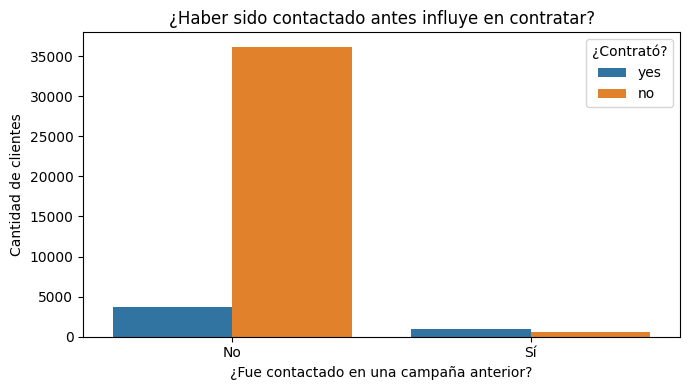

contactado_antes  tasa_yes
              No      9.27
              Sí     63.77


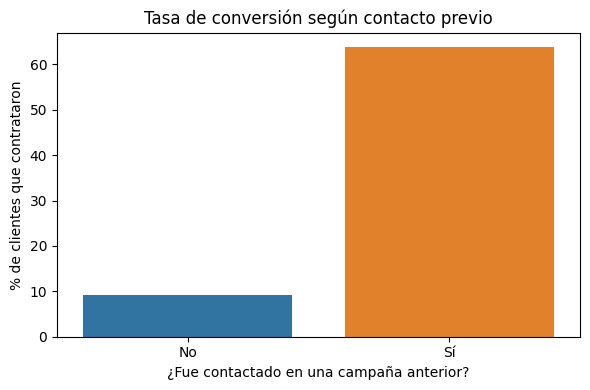

In [39]:
# PASO 1: Contamos cuántos clientes, según contacto previo, contrataron o no
plt.figure(figsize=(7, 4))
sns.countplot(data=df_rev, x='contactado_antes', hue='y')
plt.title("¿Haber sido contactado antes influye en contratar?")
plt.xlabel("¿Fue contactado en una campaña anterior?")
plt.ylabel("Cantidad de clientes")
plt.legend(title='¿Contrató?')
plt.tight_layout()
plt.show()

# PASO 2: Calculamos la tasa de conversión según contacto previo
tasa_cont = (df_rev.groupby('contactado_antes')['y']
             .apply(lambda x: round((x == 'yes').mean() * 100, 2))
             .reset_index(name='tasa_yes'))

print(tasa_cont.to_string(index=False))

plt.figure(figsize=(6, 4))
sns.barplot(data=tasa_cont, x='contactado_antes', y='tasa_yes', hue='contactado_antes')
plt.title("Tasa de conversión según contacto previo")
plt.xlabel("¿Fue contactado en una campaña anterior?")
plt.ylabel("% de clientes que contrataron")
plt.tight_layout()
plt.show()

## Análisis variables de cliente: "default", "housing", "loan"

Estas tres variables indican si el cliente tiene deudas o préstamos activos:
- **default**: ¿tiene crédito en mora (impagado)?
- **housing**: ¿tiene préstamo hipotecario?
- **loan**: ¿tiene préstamo personal?

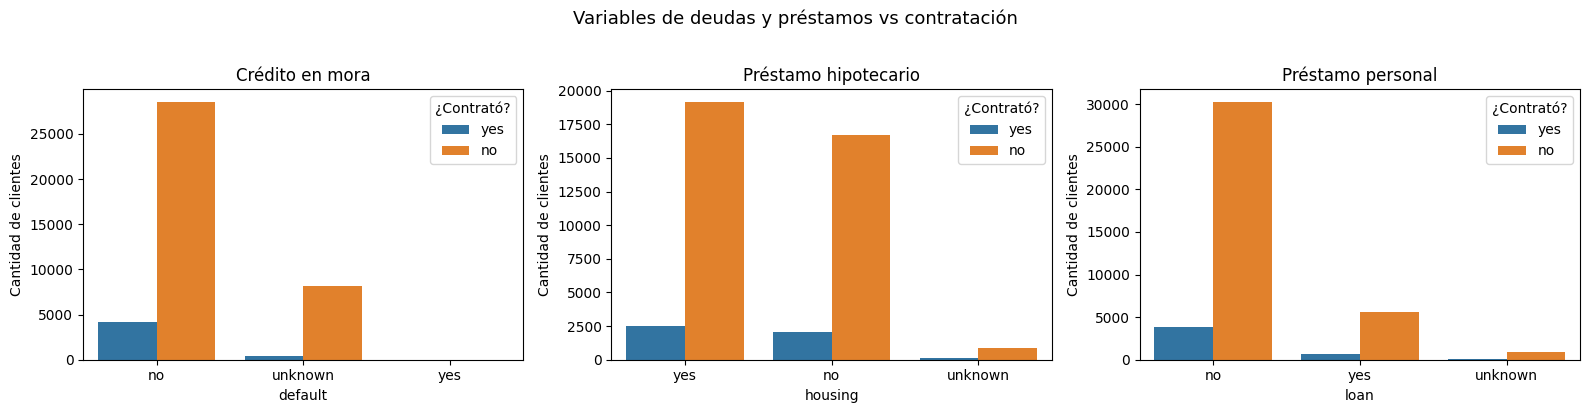

In [40]:
# Analizamos las tres variables juntas en una misma figura
# Esto permite comparar visualmente cuál tiene más impacto

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

variables = ['default', 'housing', 'loan']
titulos   = ['Crédito en mora', 'Préstamo hipotecario', 'Préstamo personal']

for ax, var, titulo in zip(axes, variables, titulos):
    # sns.countplot agrupa automáticamente y colorea según 'y'
    sns.countplot(data=df_rev, x=var, hue='y', ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(var)
    ax.set_ylabel("Cantidad de clientes")
    ax.legend(title='¿Contrató?')

plt.suptitle("Variables de deudas y préstamos vs contratación", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [41]:
# Calculamos la tasa de conversión para cada variable
# Usamos un bucle para no repetir el mismo código tres veces

for var, titulo in zip(variables, titulos):
    tasa = (df_rev.groupby(var)['y'].apply(lambda x: round((x == 'yes').mean() * 100, 2)).reset_index(name='tasa_yes'))
    tasa = tasa.sort_values('tasa_yes', ascending=False)
    print(f"\n--- {titulo} ({var}) ---")
    print(tasa.to_string(index=False))


--- Crédito en mora (default) ---
default  tasa_yes
     no     12.89
unknown      5.15
    yes      0.00

--- Préstamo hipotecario (housing) ---
housing  tasa_yes
    yes     11.66
     no     10.85
unknown     10.74

--- Préstamo personal (loan) ---
   loan  tasa_yes
     no     11.35
    yes     10.92
unknown     10.74


## Análisis "duration" (duración de la llamada)

> ⚠️ **Nota importante:** La duración de la llamada no se conoce antes de realizarla, por lo que no debe usarse como variable predictiva en un modelo real. Sin embargo, es útil para entender el comportamiento de los datos (benchmark).

count    41376.00
mean       257.07
std        259.30
min          0.00
25%        101.00
50%        179.00
75%        318.00
max       4918.00
Name: duration, dtype: float64

Duración promedio en minutos: 4.28 min


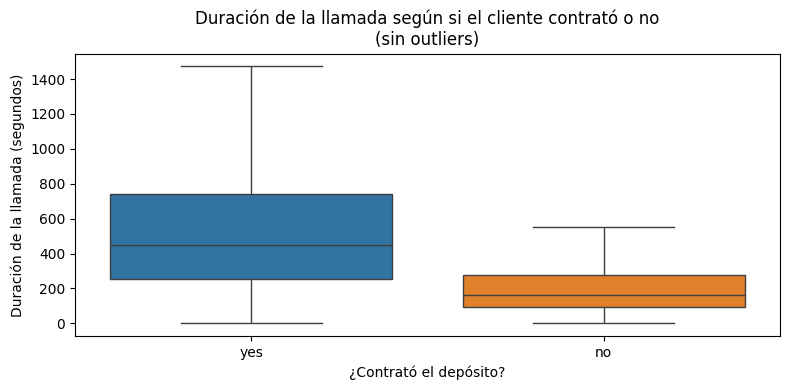

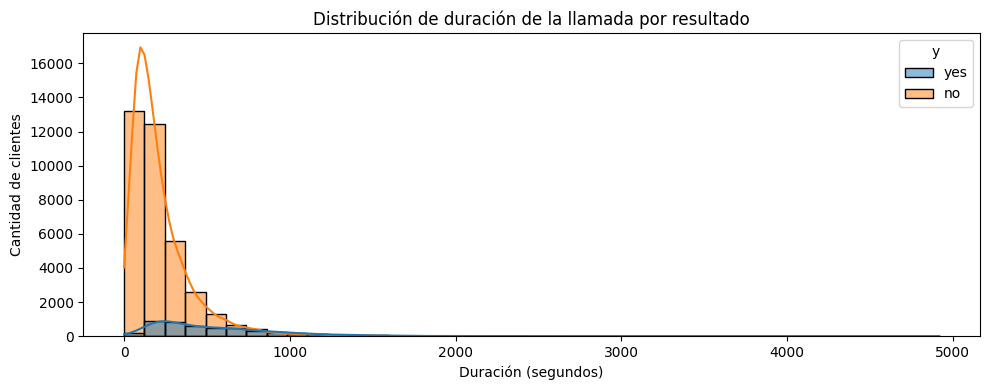

In [42]:
# Estadísticas básicas de la duración
print(df_rev['duration'].describe().round(2))
print(f"\nDuración promedio en minutos: {round(df_rev['duration'].mean() / 60, 2)} min")

# Comparamos la distribución de duración entre clientes que contrataron y los que no
# Boxplot para comparar distribuciones entre grupos
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_rev, x='y', y='duration', hue = 'y', showfliers=False)
plt.title("Duración de la llamada según si el cliente contrató o no\n(sin outliers)")
plt.xlabel("¿Contrató el depósito?")
plt.ylabel("Duración de la llamada (segundos)")
plt.tight_layout()
plt.show()

# Distribución completa con histograma separado por grupo
plt.figure(figsize=(10, 4))
sns.histplot(data=df_rev, x='duration', hue='y', bins=40, kde=True)
plt.title("Distribución de duración de la llamada por resultado")
plt.xlabel("Duración (segundos)")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

## Análisis variables económicas y de contexto

Estas variables reflejan el estado de la economía en el momento del contacto:
- **emp.var.rate**: tasa de variación del empleo (trimestral)
- **cons.price.idx**: índice de precios al consumidor (mensual)
- **cons.conf.idx**: índice de confianza del consumidor (mensual)
- **euribor3m**: tasa de interés interbancaria a 3 meses (diaria)
- **nr.employed**: número de empleados en la economía (trimestral)

La idea es ver si el contexto económico en el que se realizó el contacto influye en si el cliente contrató o no.

In [43]:
# Estadísticas básicas de las variables económicas
vars_eco = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df_rev[vars_eco].describe().round(2)

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41376.00,41376.00,41376.00,41376.00,41376.00
mean,0.08,93.58,-40.50,3.62,5167.04
std,1.57,0.58,4.63,1.73,72.24
min,-3.40,92.20,-50.80,0.63,4963.60
25%,-1.80,93.08,-42.70,1.34,5099.10
50%,1.10,93.75,-41.80,4.86,5191.00
75%,1.40,93.99,-36.40,4.96,5228.10
max,1.40,94.77,-26.90,5.04,5228.10


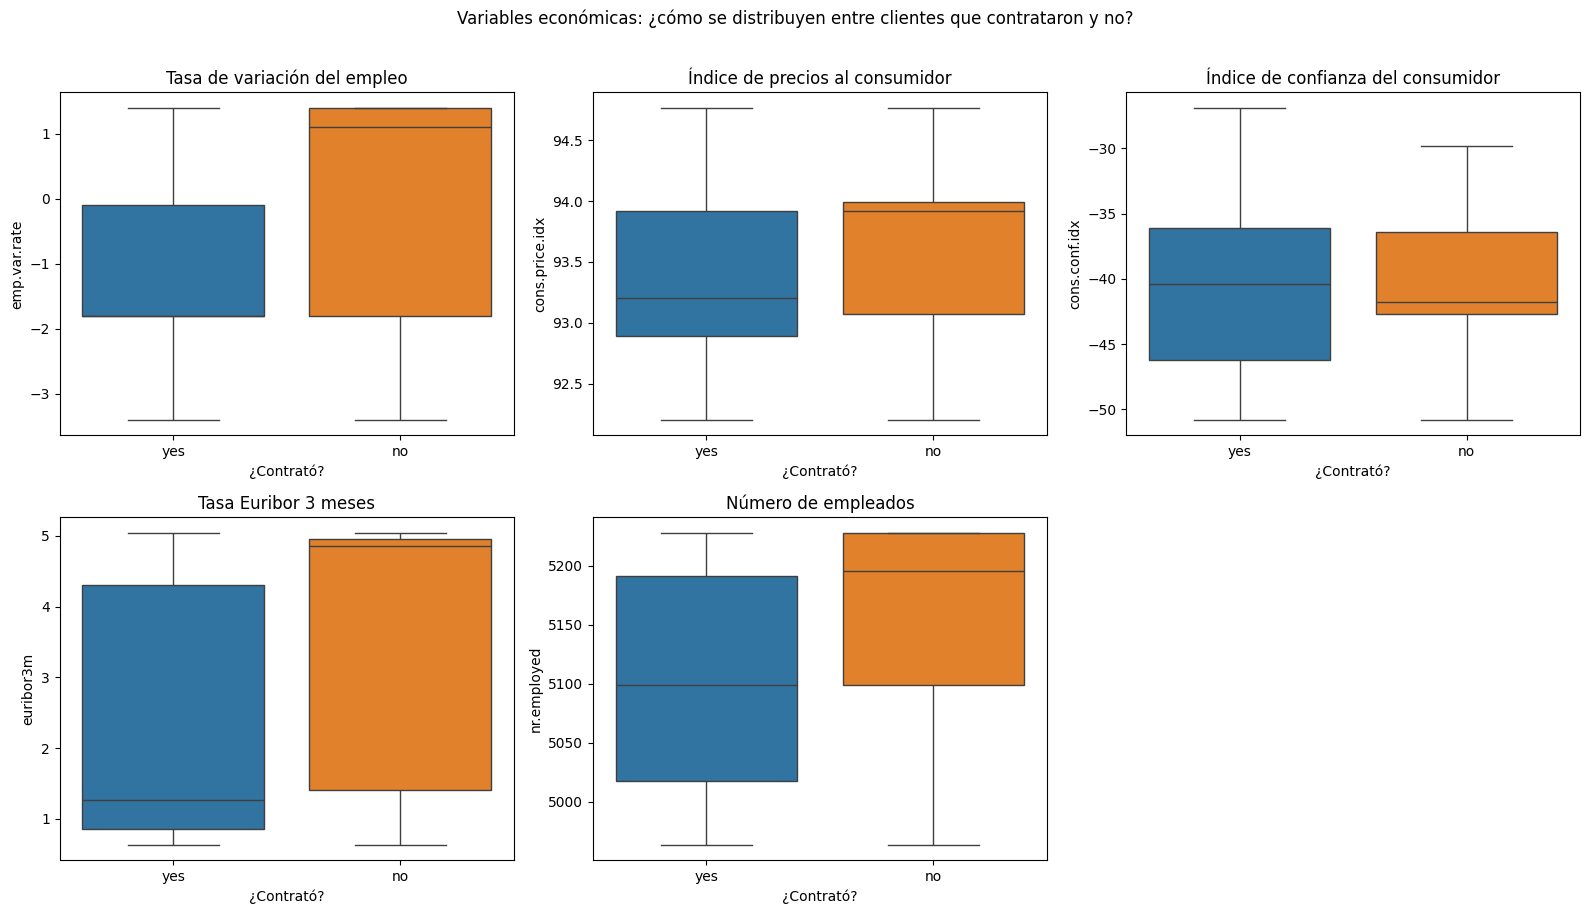

In [44]:
# Usamos boxplots para comparar cada variable económica entre clientes que contrataron y no
# Un boxplot muestra la mediana, el rango y los valores atípicos de cada grupo

titulos_eco = [
    'Tasa de variación del empleo',
    'Índice de precios al consumidor',
    'Índice de confianza del consumidor',
    'Tasa Euribor 3 meses',
    'Número de empleados'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()  # Convertimos la cuadrícula en una lista para iterar fácilmente

for i, (var, titulo) in enumerate(zip(vars_eco, titulos_eco)):
    sns.boxplot(data=df_rev, x='y', y=var, showfliers=False, hue = 'y', ax=axes[i])
    axes[i].set_title(titulo)
    axes[i].set_xlabel("¿Contrató?")
    axes[i].set_ylabel(var)

# Ocultamos el último subplot que queda vacío
axes[-1].set_visible(False)

plt.suptitle("Variables económicas: ¿cómo se distribuyen entre clientes que contrataron y no?", y=1.01)
plt.tight_layout()
plt.show()

## Parte 2: Análisis bivariado — ¿Cómo se relaciona cada variable con el resultado "y"?

En esta sección exploramos cómo cada variable se comporta de forma distinta entre los clientes que **sí contrataron** "yes" y los que **no contrataron** "no".

Esto nos ayuda a identificar qué variables tienen mayor impacto en el resultado y a responder preguntas de negocio.

### Distribución de la variable objetivo `y`

Antes de comparar variables, veamos cuántos clientes contrataron y cuántos no.

Cantidad de clientes por resultado:
y
no     36712
yes     4664
Name: count, dtype: int64

Porcentaje:
y
no     88.73
yes    11.27
Name: count, dtype: float64


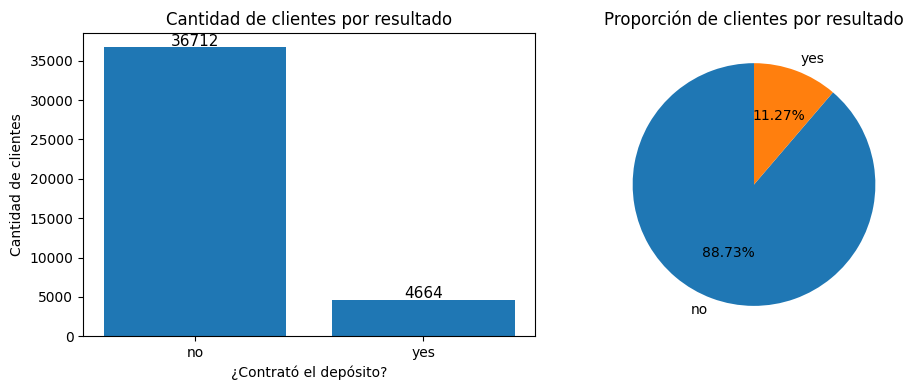

In [45]:
# Contamos cuántos clientes hay en cada categoría de 'y'
conteo_y = df_rev['y'].value_counts()
print("Cantidad de clientes por resultado:")
print(conteo_y)

# Calculamos el porcentaje de cada grupo
porcentaje_y = (conteo_y / len(df_rev) * 100).round(2)
print("\nPorcentaje:")
print(porcentaje_y)

# Graficamos con dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras: muestra el conteo absoluto
axes[0].bar(conteo_y.index, conteo_y.values)
axes[0].set_title("Cantidad de clientes por resultado")
axes[0].set_xlabel("¿Contrató el depósito?")
axes[0].set_ylabel("Cantidad de clientes")
for i, v in enumerate(conteo_y.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=11)

# Gráfico de torta: muestra la proporción
axes[1].pie(conteo_y.values,
            labels=conteo_y.index,
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title("Proporción de clientes por resultado")

plt.tight_layout()
plt.show()

### Variables numéricas vs "y"

Para variables numéricas (age, campaign, previous) usamos un boxplot comparando los dos grupos.

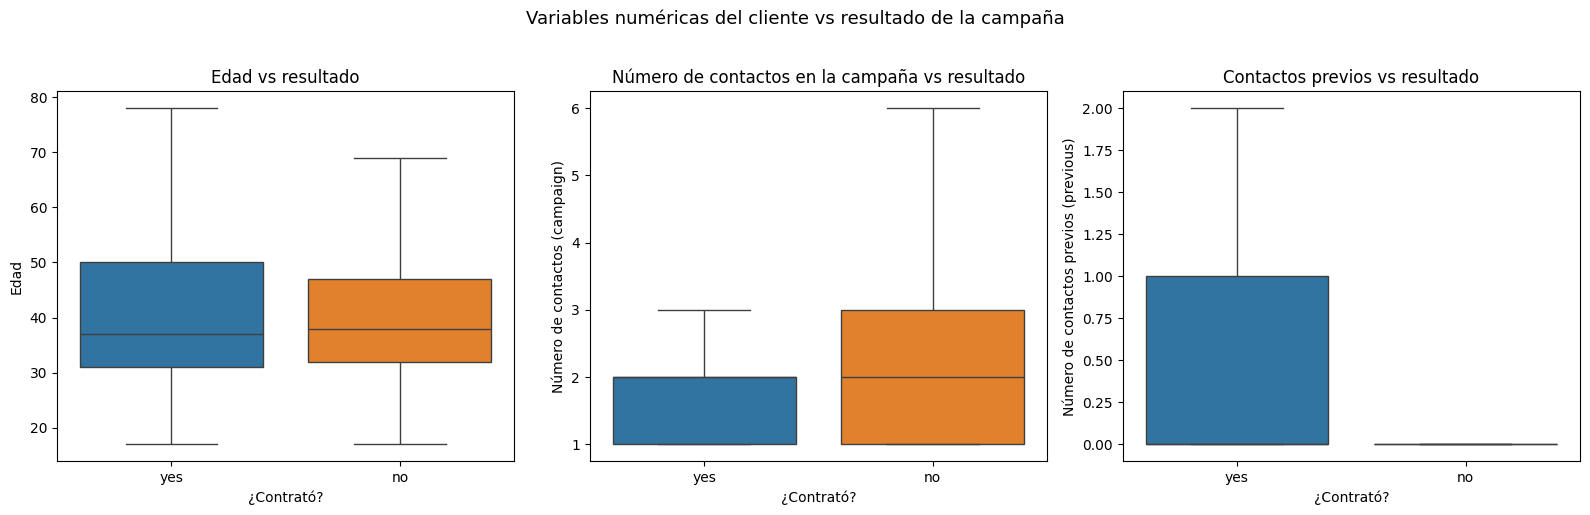

In [46]:
# Comparamos la distribución de las variables numéricas entre clientes que contrataron y no
# showfliers=False oculta los valores extremos para que el gráfico sea más claro

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# age vs y
# Pregunta: ¿Los clientes de cierta edad tienen más probabilidad de contratar?
sns.boxplot(data=df_rev, x='y', y='age', showfliers=False, ax=axes[0], hue='y')
axes[0].set_title("Edad vs resultado")
axes[0].set_xlabel("¿Contrató?")
axes[0].set_ylabel("Edad")

# campaign vs y
# Pregunta: ¿Los clientes que recibieron más llamadas son más o menos propensos a contratar?
sns.boxplot(data=df_rev, x='y', y='campaign', showfliers=False, ax=axes[1], hue='y')
axes[1].set_title("Número de contactos en la campaña vs resultado")
axes[1].set_xlabel("¿Contrató?")
axes[1].set_ylabel("Número de contactos (campaign)")

# previous vs y
# Pregunta: ¿Haber sido contactado más veces antes influye en el resultado?
sns.boxplot(data=df_rev, x='y', y='previous', showfliers=False, ax=axes[2], hue='y')
axes[2].set_title("Contactos previos vs resultado")
axes[2].set_xlabel("¿Contrató?")
axes[2].set_ylabel("Número de contactos previos (previous)")

plt.suptitle("Variables numéricas del cliente vs resultado de la campaña", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Rango de edad "q_age" vs "y"

Usamos la variable creada "q_age" para ver si algún grupo de edad tiene mayor tasa de conversión.  
**Tasa de conversión** = porcentaje de clientes de ese grupo que dijeron "yes".

Cantidad de clientes por rango de edad:
q_age
Q1 (17-32)    11218
Q3 (38-47)    10191
Q2 (32-38)    10050
Q4 (47-98)     9917
Name: count, dtype: int64

Porcentaje:
q_age
Q1 (17-32)    27.11
Q3 (38-47)    24.63
Q2 (32-38)    24.29
Q4 (47-98)    23.97
Name: count, dtype: float64


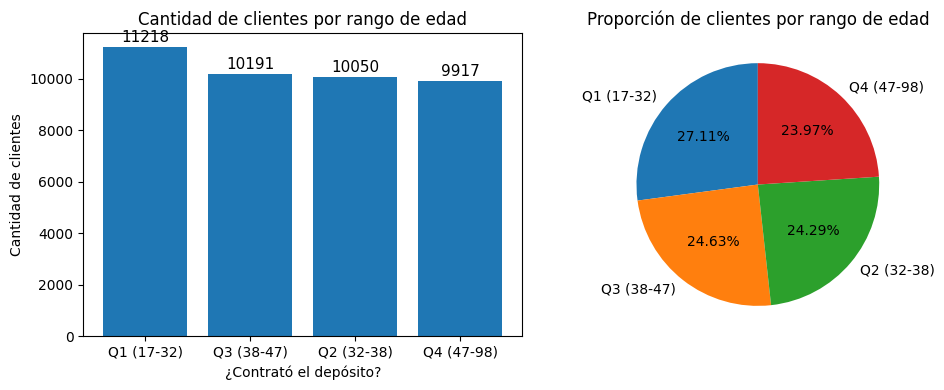

In [47]:
# Contamos cuántos clientes hay en cada categoría de 'y'
conteo_age = df_rev['q_age'].value_counts()
print("Cantidad de clientes por rango de edad:")
print(conteo_age)

# Calculamos el porcentaje de cada grupo
porcentaje_age = (conteo_age / len(df_rev) * 100).round(2)
print("\nPorcentaje:")
print(porcentaje_age)

# Graficamos con dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras: muestra el conteo absoluto
axes[0].bar(conteo_age.index, conteo_age.values)
axes[0].set_title("Cantidad de clientes por rango de edad")
axes[0].set_xlabel("¿Contrató el depósito?")
axes[0].set_ylabel("Cantidad de clientes")
for i, v in enumerate(conteo_age.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=11)

# Gráfico de torta: muestra la proporción
axes[1].pie(conteo_age.values,
            labels=conteo_age.index,
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title("Proporción de clientes por rango de edad")

plt.tight_layout()
plt.show()

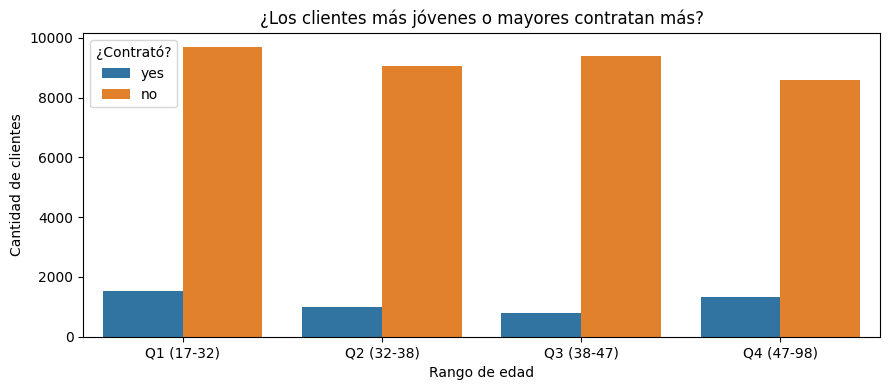

Tasa de conversión por rango de edad:
     q_age  tasa_yes (%)
Q1 (17-32)         13.70
Q2 (32-38)          9.95
Q3 (38-47)          7.84
Q4 (47-98)         13.39


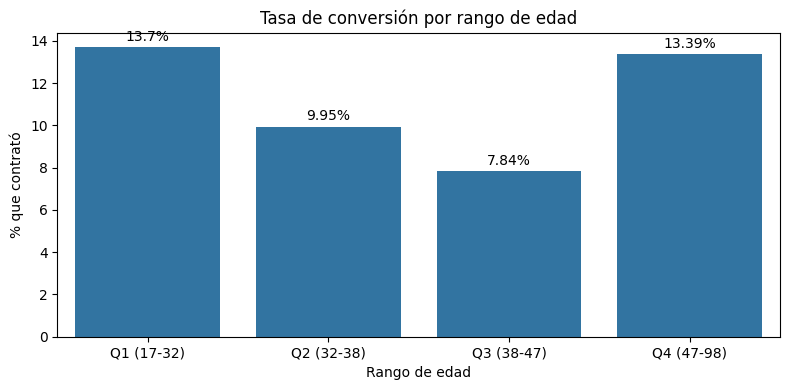

In [48]:
# Conteo de clientes por rango de edad y resultado
# hue='y' colorea las barras según si el cliente contrató o no
plt.figure(figsize=(9, 4))
sns.countplot(data=df_rev, x='q_age', hue='y')
plt.title("¿Los clientes más jóvenes o mayores contratan más?")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de clientes")
plt.legend(title='¿Contrató?')
plt.tight_layout()
plt.show()

# Tasa de conversión por rango de edad
# groupby agrupa por q_age, luego calculamos el % de 'yes' en cada grupo
tasa_edad = (df_rev.groupby('q_age', observed=True)['y']
             .apply(lambda x: round((x == 'yes').mean() * 100, 2))
             .reset_index(name='tasa_yes (%)'))

print("Tasa de conversión por rango de edad:")
print(tasa_edad.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=tasa_edad, x='q_age', y='tasa_yes (%)')
plt.title("Tasa de conversión por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("% que contrató")
for i, row in tasa_edad.iterrows():
    plt.text(i, row['tasa_yes (%)'] + 0.3, f"{row['tasa_yes (%)']}%",
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [49]:
# Tabla cruzada
ct_age = pd.crosstab(df_rev['q_age'], df_rev['y'], margins=True)
print("Tabla cruzada — Rango de edad vs contratación (conteos):")
ct_age

Tabla cruzada — Rango de edad vs contratación (conteos):


y,no,yes,All
q_age,,,
Q1 (17-32),9681,1537,11218
Q2 (32-38),9050,1000,10050
Q3 (38-47),9392,799,10191
Q4 (47-98),8589,1328,9917
All,36712,4664,41376


In [50]:
# Tabla cruzada normalizada
ct_age_pct = pd.crosstab(df_rev['q_age'], df_rev['y'], normalize='index', margins=True) * 100
ct_age_pct = ct_age_pct.round(2)
print("\nEn porcentaje:")
ct_age_pct


En porcentaje:


y,no,yes
q_age,,
Q1 (17-32),86.30,13.70
Q2 (32-38),90.05,9.95
Q3 (38-47),92.16,7.84
Q4 (47-98),86.61,13.39
All,88.73,11.27


### Categoría de empleo "job_cat" vs "y"

Usamos la variable creada "job_cat" que agrupa los tipos de trabajo en: **Formal**, **Informal**, **No Remunerado** y **Otros**.

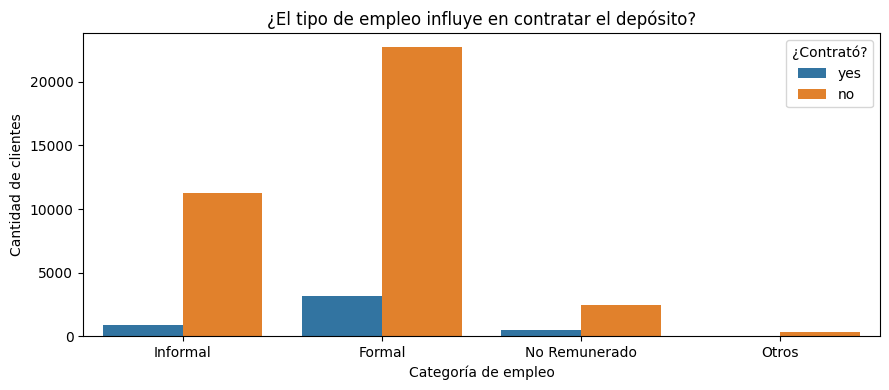

Tasa de conversión por categoría de empleo:
      job_cat  tasa_yes (%)
No Remunerado         17.83
       Formal         12.29
        Otros         11.08
     Informal          7.52


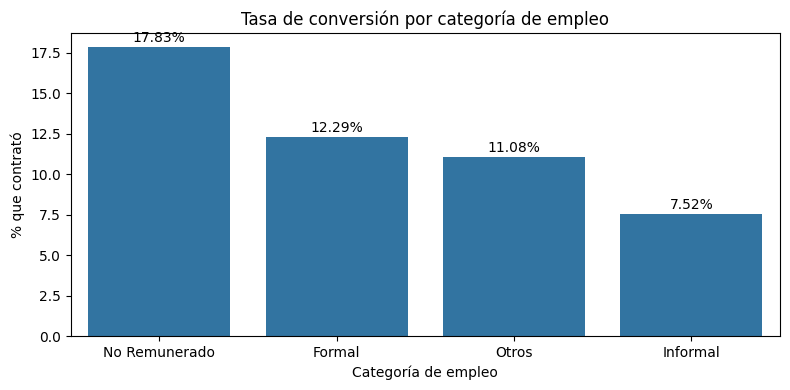

In [51]:
# Distribución de resultado por categoría de empleo
plt.figure(figsize=(9, 4))
sns.countplot(data=df_rev, x='job_cat', hue='y')
plt.title("¿El tipo de empleo influye en contratar el depósito?")
plt.xlabel("Categoría de empleo")
plt.ylabel("Cantidad de clientes")
plt.legend(title='¿Contrató?')
plt.tight_layout()
plt.show()

# Tasa de conversión por categoría de empleo
tasa_job = (df_rev.groupby('job_cat')['y']
            .apply(lambda x: round((x == 'yes').mean() * 100, 2))
            .reset_index(name='tasa_yes (%)'))
tasa_job = tasa_job.sort_values('tasa_yes (%)', ascending=False)

print("Tasa de conversión por categoría de empleo:")
print(tasa_job.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=tasa_job, x='job_cat', y='tasa_yes (%)')
plt.title("Tasa de conversión por categoría de empleo")
plt.xlabel("Categoría de empleo")
plt.ylabel("% que contrató")
for i, row in tasa_job.reset_index(drop=True).iterrows():
    plt.text(i, row['tasa_yes (%)'] + 0.3, f"{row['tasa_yes (%)']}%",
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [52]:
# Tabla cruzada
ct_jobcat = pd.crosstab(df_rev['job_cat'], df_rev['y'], margins=True)
print("Tabla cruzada — Categoría de empleo vs contratación (conteos):")
ct_jobcat

Tabla cruzada — Categoría de empleo vs contratación (conteos):


y,no,yes,All
job_cat,,,
Formal,22714,3183,25897
Informal,11268,916,12184
No Remunerado,2433,528,2961
Otros,297,37,334
All,36712,4664,41376


In [53]:
# Tabla cruzada normalizada
ct_jobcat_pct = pd.crosstab(df_rev['job_cat'], df_rev['y'], normalize='index', margins=True) * 100
ct_jobcat_pct = ct_jobcat_pct.round(2)
print("\nEn porcentaje:")
ct_jobcat_pct


En porcentaje:


y,no,yes
job_cat,,
Formal,87.71,12.29
Informal,92.48,7.52
No Remunerado,82.17,17.83
Otros,88.92,11.08
All,88.73,11.27


In [54]:
# Cruzamos rango de edad con categoría de empleo, filtrando solo los que contrataron (y='yes')
# Esto responde: ¿qué combinación de edad + empleo genera más contrataciones?
solo_yes = df_rev[df_rev['y'] == 'yes']

ct_age_job = pd.crosstab(solo_yes['q_age'], solo_yes['job_cat'], normalize='index', margins=True)*100
ct_age_job = ct_age_job.round(2)
print("Tabla cruzada — Rango de edad × Categoría de empleo (solo clientes que contrataron):")
ct_age_job

Tabla cruzada — Rango de edad × Categoría de empleo (solo clientes que contrataron):


job_cat,Formal,Informal,No Remunerado,Otros
q_age,,,,
Q1 (17-32),61.87,16.85,20.49,0.78
Q2 (32-38),71.30,22.00,6.50,0.20
Q3 (38-47),65.58,28.16,5.51,0.75
Q4 (47-98),74.92,15.96,7.83,1.28
All,68.25,19.64,11.32,0.79


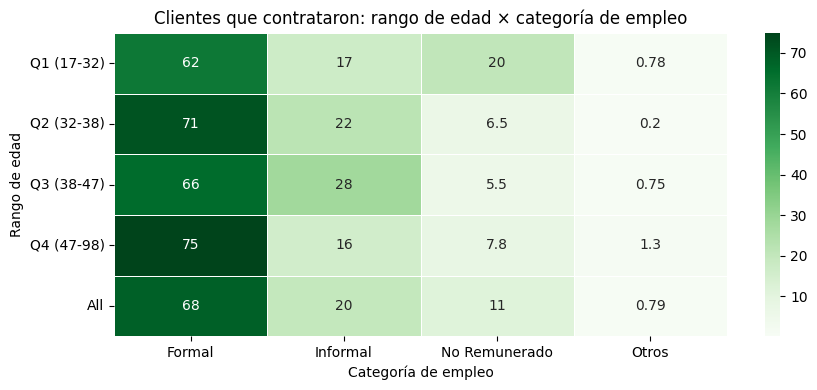

In [55]:
plt.figure(figsize=(9, 4))
sns.heatmap(ct_age_job,
            annot=True, 
            cmap='Greens',
            linewidths=0.5)
plt.title("Clientes que contrataron: rango de edad × categoría de empleo")
plt.xlabel("Categoría de empleo")
plt.ylabel("Rango de edad")
plt.tight_layout()
plt.show()

### Estado civil "marital" y educación "education" vs "y"


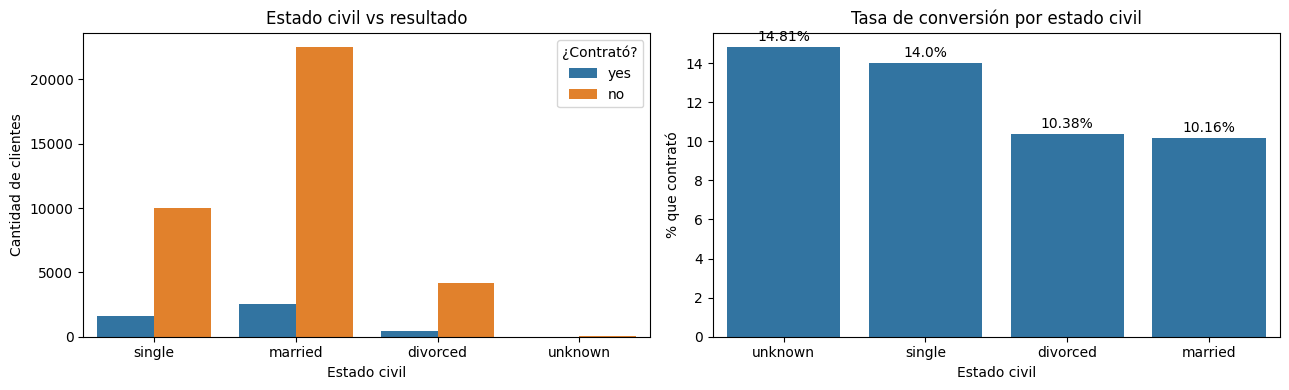

In [56]:
# Estado civil vs resultado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Conteo por categoría
sns.countplot(data=df_rev, x='marital', hue='y', ax=axes[0])
axes[0].set_title("Estado civil vs resultado")
axes[0].set_xlabel("Estado civil")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].legend(title='¿Contrató?')

# Tasa de conversión
tasa_marital = (df_rev.groupby('marital')['y']
                .apply(lambda x: round((x == 'yes').mean() * 100, 2))
                .reset_index(name='tasa_yes (%)'))
tasa_marital = tasa_marital.sort_values('tasa_yes (%)', ascending=False)

sns.barplot(data=tasa_marital, x='marital', y='tasa_yes (%)', ax=axes[1])
axes[1].set_title("Tasa de conversión por estado civil")
axes[1].set_xlabel("Estado civil")
axes[1].set_ylabel("% que contrató")
for i, row in tasa_marital.reset_index(drop=True).iterrows():
    axes[1].text(i, row['tasa_yes (%)'] + 0.3,
                 f"{row['tasa_yes (%)']}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [57]:
# Tabla cruzada
ct_marital = pd.crosstab(df_rev['marital'], df_rev['y'], margins=True)
print("Tabla cruzada — Estado civil vs contratación (conteos):")
ct_marital

Tabla cruzada — Estado civil vs contratación (conteos):


y,no,yes,All
marital,,,
divorced,4153,481,4634
married,22492,2544,25036
single,9998,1627,11625
unknown,69,12,81
All,36712,4664,41376


In [58]:
# Tabla cruzada normalizada
ct_marital_pct = pd.crosstab(df_rev['marital'], df_rev['y'], normalize='index', margins=True) * 100
ct_marital_pct = ct_marital_pct.round(2)
print("\nEn porcentaje (% dentro de cada estado civil):")
ct_marital_pct


En porcentaje (% dentro de cada estado civil):


y,no,yes
marital,,
divorced,89.62,10.38
married,89.84,10.16
single,86.00,14.00
unknown,85.19,14.81
All,88.73,11.27


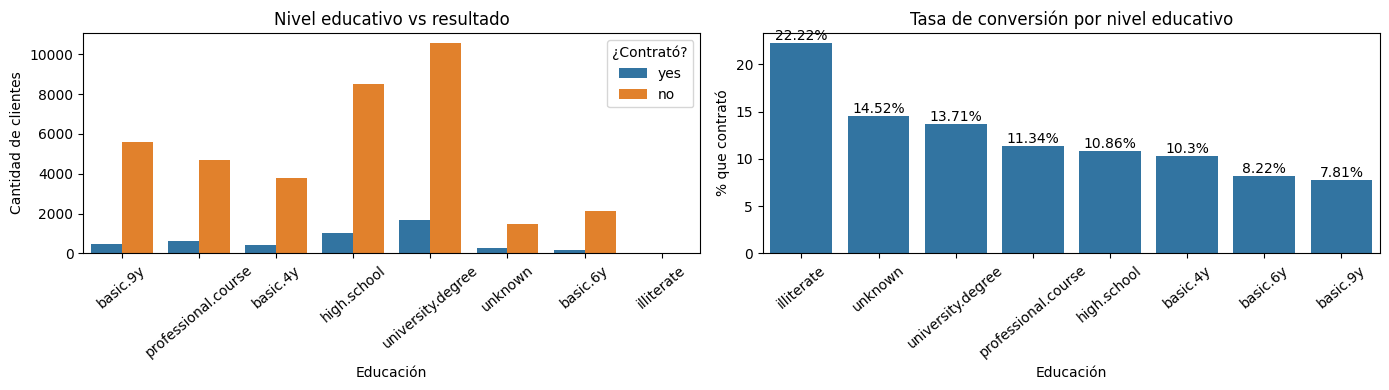

In [59]:
# Nivel educativo vs resultado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_rev, x='education', hue='y', ax=axes[0])
axes[0].set_title("Nivel educativo vs resultado")
axes[0].set_xlabel("Educación")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='¿Contrató?')

tasa_edu = (df_rev.groupby('education')['y']
            .apply(lambda x: round((x == 'yes').mean() * 100, 2))
            .reset_index(name='tasa_yes (%)'))
tasa_edu = tasa_edu.sort_values('tasa_yes (%)', ascending=False)

sns.barplot(data=tasa_edu, x='education', y='tasa_yes (%)', ax=axes[1])
axes[1].set_title("Tasa de conversión por nivel educativo")
axes[1].set_xlabel("Educación")
axes[1].set_ylabel("% que contrató")
axes[1].tick_params(axis='x', rotation=40)
for i, row in tasa_edu.reset_index(drop=True).iterrows():
    axes[1].text(i, row['tasa_yes (%)'] + 0.3,
                 f"{row['tasa_yes (%)']}%", ha='center')

plt.tight_layout()
plt.show()

In [60]:
# Tabla cruzada
ct_edu = pd.crosstab(df_rev['education'], df_rev['y'], margins=True)
print("Tabla cruzada — Educación vs contratación (conteos):")
ct_edu

Tabla cruzada — Educación vs contratación (conteos):


y,no,yes,All
education,,,
basic.4y,3770,433,4203
basic.6y,2109,189,2298
basic.9y,5594,474,6068
high.school,8517,1038,9555
illiterate,14,4,18
professional.course,4666,597,5263
university.degree,10552,1676,12228
unknown,1490,253,1743
All,36712,4664,41376


In [61]:
# Tabla cruzada normalizada
ct_edu_pct = pd.crosstab(df_rev['education'], df_rev['y'], normalize='index', margins=True) * 100
ct_edu_pct = ct_edu_pct.round(2)
print("\nEn porcentaje:")
ct_edu_pct


En porcentaje:


y,no,yes
education,,
basic.4y,89.70,10.30
basic.6y,91.78,8.22
basic.9y,92.19,7.81
high.school,89.14,10.86
illiterate,77.78,22.22
professional.course,88.66,11.34
university.degree,86.29,13.71
unknown,85.48,14.52
All,88.73,11.27


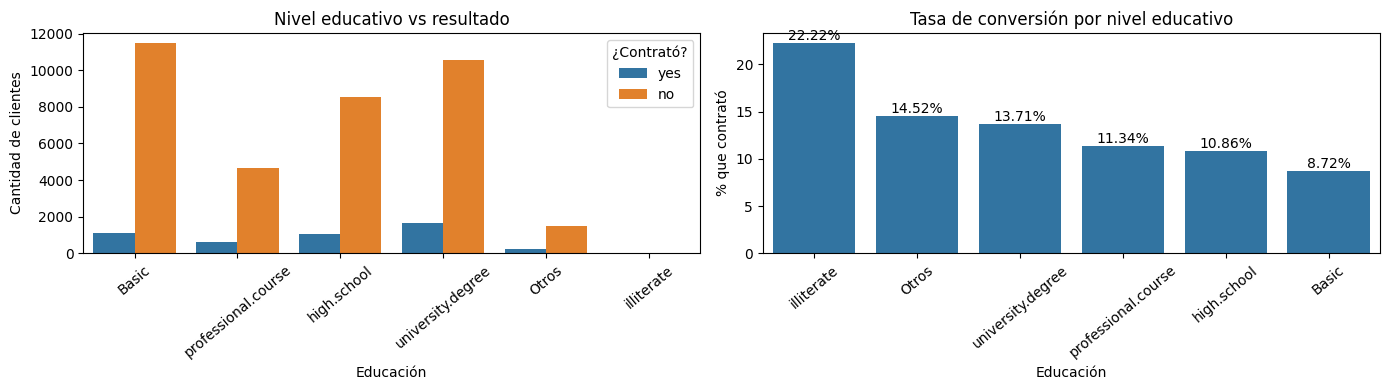

In [62]:
# Nivel educativo categorizado vs resultado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_rev, x='edu_cat', hue='y', ax=axes[0])
axes[0].set_title("Nivel educativo vs resultado")
axes[0].set_xlabel("Educación")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='¿Contrató?')

tasa_edu = (df_rev.groupby('edu_cat')['y']
            .apply(lambda x: round((x == 'yes').mean() * 100, 2))
            .reset_index(name='tasa_yes (%)'))
tasa_edu = tasa_edu.sort_values('tasa_yes (%)', ascending=False)

sns.barplot(data=tasa_edu, x='edu_cat', y='tasa_yes (%)', ax=axes[1])
axes[1].set_title("Tasa de conversión por nivel educativo")
axes[1].set_xlabel("Educación")
axes[1].set_ylabel("% que contrató")
axes[1].tick_params(axis='x', rotation=40)
for i, row in tasa_edu.reset_index(drop=True).iterrows():
    axes[1].text(i, row['tasa_yes (%)'] + 0.3,
                 f"{row['tasa_yes (%)']}%", ha='center')

plt.tight_layout()
plt.show()

In [63]:
# Tabla cruzada
ct_edu = pd.crosstab(df_rev['edu_cat'], df_rev['y'], margins=True)
print("Tabla cruzada — Educación vs contratación (conteos):")
ct_edu

Tabla cruzada — Educación vs contratación (conteos):


y,no,yes,All
edu_cat,,,
Basic,11473,1096,12569
Otros,1490,253,1743
high.school,8517,1038,9555
illiterate,14,4,18
professional.course,4666,597,5263
university.degree,10552,1676,12228
All,36712,4664,41376


In [64]:
# Tabla cruzada normalizada
ct_edu_pct = pd.crosstab(df_rev['edu_cat'], df_rev['y'], normalize='index', margins=True) * 100
ct_edu_pct = ct_edu_pct.round(2)
print("\nEn porcentaje:")
ct_edu_pct


En porcentaje:


y,no,yes
edu_cat,,
Basic,91.28,8.72
Otros,85.48,14.52
high.school,89.14,10.86
illiterate,77.78,22.22
professional.course,88.66,11.34
university.degree,86.29,13.71
All,88.73,11.27


In [65]:
# Tabla cruzada entre "Estado Civil" y "nivel educativo"
ct_mar_edu = pd.crosstab(df_rev['marital'], df_rev['edu_cat'], normalize='index', margins=True)*100
ct_mar_edu = ct_mar_edu.round(2)
print("Tabla cruzada — Estado civil × Educación (porcentaje):")
ct_mar_edu

Tabla cruzada — Estado civil × Educación (porcentaje):


edu_cat,Basic,Otros,high.school,illiterate,professional.course,university.degree
marital,,,,,,
divorced,26.80,4.04,25.87,0.04,14.22,29.02
married,36.71,4.24,20.69,0.06,12.65,25.65
single,18.21,4.16,27.21,0.01,12.30,38.11
unknown,24.69,12.35,17.28,0.00,7.41,38.27
All,30.38,4.21,23.09,0.04,12.72,29.55


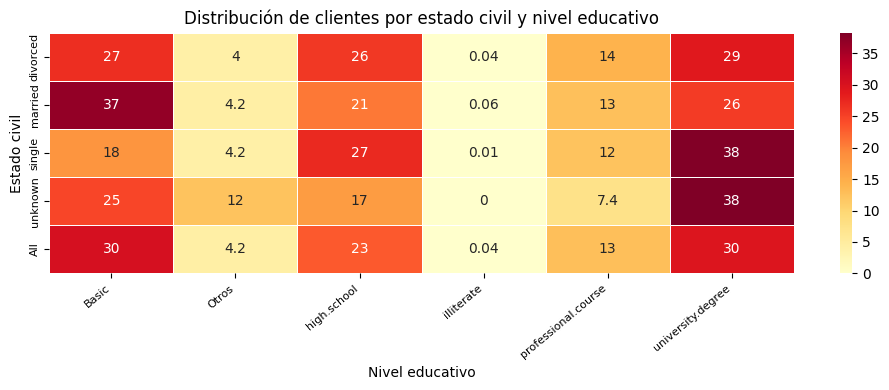

In [66]:
plt.figure(figsize=(10, 4))
sns.heatmap(ct_mar_edu,
            annot=True,        
            cmap='YlOrRd',
            linewidths=0.5)
plt.title("Distribución de clientes por estado civil y nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Estado civil")
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Variables de contacto: "contact", "month", "day_of_week" vs "y"

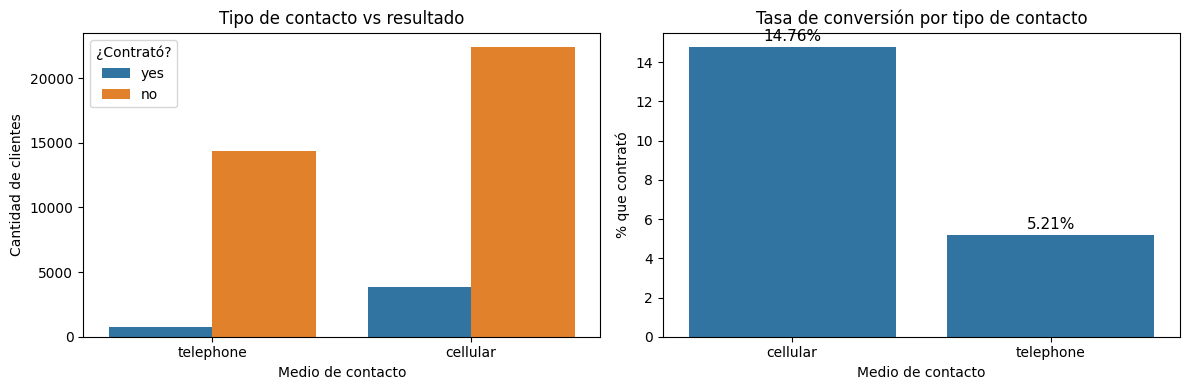

In [67]:
# Tipo de contacto vs resultado
# Pregunta: ¿Es más efectivo contactar por celular o por teléfono fijo?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_rev, x='contact', hue='y', ax=axes[0])
axes[0].set_title("Tipo de contacto vs resultado")
axes[0].set_xlabel("Medio de contacto")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].legend(title='¿Contrató?')

tasa_contact = (df_rev.groupby('contact')['y']
                .apply(lambda x: round((x == 'yes').mean() * 100, 2))
                .reset_index(name='tasa_yes (%)'))

sns.barplot(data=tasa_contact, x='contact', y='tasa_yes (%)', ax=axes[1])
axes[1].set_title("Tasa de conversión por tipo de contacto")
axes[1].set_xlabel("Medio de contacto")
axes[1].set_ylabel("% que contrató")
for i, row in tasa_contact.iterrows():
    axes[1].text(i, row['tasa_yes (%)'] + 0.3,
                 f"{row['tasa_yes (%)']}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [68]:
# Tabla cruzada
ct_contact = pd.crosstab(df_rev['contact'], df_rev['y'], margins=True)
print("Tabla cruzada — Tipo de contacto vs contratación (conteos):")
ct_contact

Tabla cruzada — Tipo de contacto vs contratación (conteos):


y,no,yes,All
contact,,,
cellular,22384,3876,26260
telephone,14328,788,15116
All,36712,4664,41376


In [69]:
# Tabla cruzada normalizada
ct_contact_pct = pd.crosstab(df_rev['contact'], df_rev['y'], normalize='index', margins=True) * 100
ct_contact_pct = ct_contact_pct.round(2)
print("\nEn porcentaje:")
ct_contact_pct


En porcentaje:


y,no,yes
contact,,
cellular,85.24,14.76
telephone,94.79,5.21
All,88.73,11.27


In [70]:
# Tabla cruzada entre "Tipo de contacto" y "rango de edad"
ct_contact_age = pd.crosstab(df_rev['q_age'], df_rev['contact'], normalize='index', margins=True)*100
ct_contact_age = ct_contact_age.round(2)
print("Tabla cruzada — Tipo de contacto × Edad (porcentaje):")
ct_contact_age

Tabla cruzada — Tipo de contacto × Edad (porcentaje):


contact,cellular,telephone
q_age,,
Q1 (17-32),68.08,31.92
Q2 (32-38),62.50,37.50
Q3 (38-47),58.22,41.78
Q4 (47-98),64.63,35.37
All,63.47,36.53


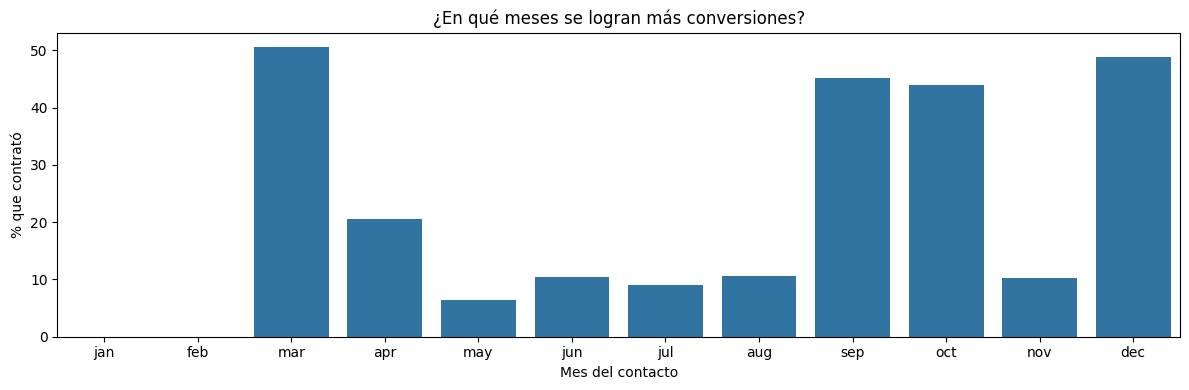

In [71]:
# Mes del contacto vs resultado
# Ordenamos los meses de forma cronológica para que el gráfico tenga sentido
orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Calculamos la tasa de conversión y reordenamos según el orden de meses
tasa_mes = (df_rev.groupby('month')['y']
            .apply(lambda x: round((x == 'yes').mean() * 100, 2))
            .reset_index(name='tasa_yes (%)'))
tasa_mes['month'] = pd.Categorical(tasa_mes['month'], categories=orden_meses, ordered=True)
tasa_mes = tasa_mes.sort_values('month')

plt.figure(figsize=(12, 4))
sns.barplot(data=tasa_mes, x='month', y='tasa_yes (%)')
plt.title("¿En qué meses se logran más conversiones?")
plt.xlabel("Mes del contacto")
plt.ylabel("% que contrató")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

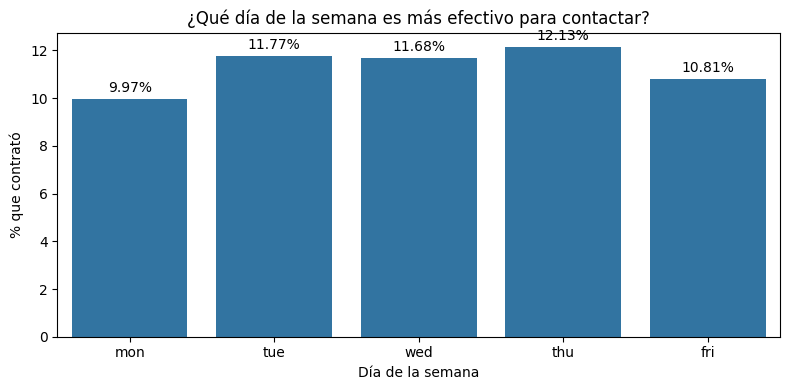

In [72]:
# Día de la semana vs resultado
# Ordenamos de lunes a viernes
orden_dias = ['mon', 'tue', 'wed', 'thu', 'fri']

tasa_dia = (df_rev.groupby('day_of_week')['y']
            .apply(lambda x: round((x == 'yes').mean() * 100, 2))
            .reset_index(name='tasa_yes (%)'))
tasa_dia['day_of_week'] = pd.Categorical(tasa_dia['day_of_week'], categories=orden_dias, ordered=True)
tasa_dia = tasa_dia.sort_values('day_of_week')

plt.figure(figsize=(8, 4))
sns.barplot(data=tasa_dia, x='day_of_week', y='tasa_yes (%)')
plt.title("¿Qué día de la semana es más efectivo para contactar?")
plt.xlabel("Día de la semana")
plt.ylabel("% que contrató")
for i, row in tasa_dia.reset_index(drop=True).iterrows():
    plt.text(i, row['tasa_yes (%)'] + 0.3,
             f"{row['tasa_yes (%)']}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Resultado de la campaña anterior "poutcome" vs "y"

"poutcome" indica si el cliente ya participó en una campaña anterior y cuál fue el resultado (success, failure, nonexistent).  
**Pregunta de negocio:** ¿Los clientes que ya aceptaron antes vuelven a contratar?

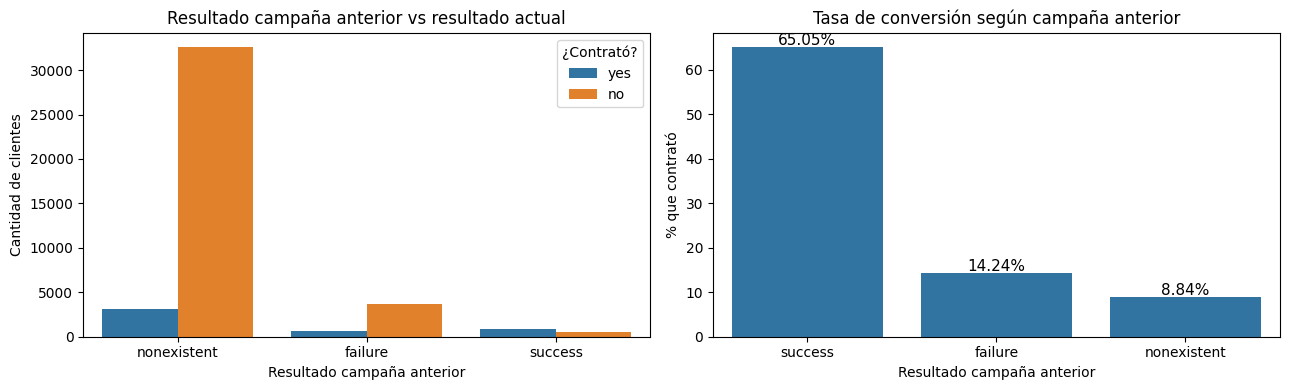

In [73]:
# Resultado campaña anterior vs resultado actual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df_rev, x='poutcome', hue='y', ax=axes[0])
axes[0].set_title("Resultado campaña anterior vs resultado actual")
axes[0].set_xlabel("Resultado campaña anterior")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].legend(title='¿Contrató?')

tasa_pout = (df_rev.groupby('poutcome')['y']
             .apply(lambda x: round((x == 'yes').mean() * 100, 2))
             .reset_index(name='tasa_yes (%)'))
tasa_pout = tasa_pout.sort_values('tasa_yes (%)', ascending=False)

sns.barplot(data=tasa_pout, x='poutcome', y='tasa_yes (%)', ax=axes[1])
axes[1].set_title("Tasa de conversión según campaña anterior")
axes[1].set_xlabel("Resultado campaña anterior")
axes[1].set_ylabel("% que contrató")
for i, row in tasa_pout.reset_index(drop=True).iterrows():
    axes[1].text(i, row['tasa_yes (%)'] + 0.5,
                 f"{row['tasa_yes (%)']}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [74]:
# Tabla cruzada
ct_pout = pd.crosstab(df_rev['poutcome'], df_rev['y'], margins=True)
print("Tabla cruzada — Resultado campaña anterior vs contratación (conteos):")
ct_pout

Tabla cruzada — Resultado campaña anterior vs contratación (conteos):


y,no,yes,All
poutcome,,,
failure,3662,608,4270
nonexistent,32568,3159,35727
success,482,897,1379
All,36712,4664,41376


In [75]:
# Tabla cruzada normalizada
ct_pout_pct = pd.crosstab(df_rev['poutcome'], df_rev['y'], normalize='index', margins=True) * 100
ct_pout_pct = ct_pout_pct.round(2)
print("\nEn porcentaje:")
ct_pout_pct


En porcentaje:


y,no,yes
poutcome,,
failure,85.76,14.24
nonexistent,91.16,8.84
success,34.95,65.05
All,88.73,11.27


In [76]:
df_rev['poutcome'].value_counts()

poutcome
nonexistent    35727
failure         4270
success         1379
Name: count, dtype: int64